In [41]:
%matplotlib inline

In [1]:
import numpy as np

from openaerostruct.meshing.mesh_generator import generate_mesh

from openaerostruct.integration.aerostruct_groups import AerostructGeometry, AerostructPoint

import openmdao.api as om
from openaerostruct.utils.constants import grav_constant

# Create a dictionary to store options about the surface
mesh_dict = {"num_y": 5, "num_x": 2, "wing_type": "CRM", "symmetry": True, "num_twist_cp": 5}

mesh, twist_cp = generate_mesh(mesh_dict)

surface = {
    # Wing definition
    "name": "wing",  # name of the surface
    "symmetry": True,  # if true, model one half of wing
    # reflected across the plane y = 0
    "S_ref_type": "wetted",  # how we compute the wing area,
    # can be 'wetted' or 'projected'
    "fem_model_type": "tube",
    "thickness_cp": np.array([0.1, 0.2, 0.3]),
    "twist_cp": twist_cp,
    "mesh": mesh,
    # Aerodynamic performance of the lifting surface at
    # an angle of attack of 0 (alpha=0).
    # These CL0 and CD0 values are added to the CL and CD
    # obtained from aerodynamic analysis of the surface to get
    # the total CL and CD.
    # These CL0 and CD0 values do not vary wrt alpha.
    "CL0": 0.0,  # CL of the surface at alpha=0
    "CD0": 0.015,  # CD of the surface at alpha=0
    # Airfoil properties for viscous drag calculation
    "k_lam": 0.05,  # percentage of chord with laminar
    # flow, used for viscous drag
    "t_over_c_cp": np.array([0.15]),  # thickness over chord ratio (NACA0015)
    "c_max_t": 0.303,  # chordwise location of maximum (NACA0015)
    # thickness
    "with_viscous": True,
    "with_wave": False,  # if true, compute wave drag
    # Structural values are based on aluminum 7075
    "E": 70.0e9,  # [Pa] Young's modulus of the spar
    "G": 30.0e9,  # [Pa] shear modulus of the spar
    "yield": 500.0e6 / 2.5,  # [Pa] yield stress divided by 2.5 for limiting case
    "mrho": 3.0e3,  # [kg/m^3] material density
    "fem_origin": 0.35,  # normalized chordwise location of the spar
    "wing_weight_ratio": 2.0,
    "struct_weight_relief": False,  # True to add the weight of the structure to the loads on the structure
    "distributed_fuel_weight": False,
    # Constraints
    "exact_failure_constraint": False,  # if false, use KS function
}

# Create the problem and assign the model group
prob = om.Problem()

# Add problem information as an independent variables component
indep_var_comp = om.IndepVarComp()
indep_var_comp.add_output("v", val=248.136, units="m/s")
indep_var_comp.add_output("alpha", val=5.0, units="deg")
indep_var_comp.add_output("Mach_number", val=0.84)
indep_var_comp.add_output("re", val=1.0e6, units="1/m")
indep_var_comp.add_output("rho", val=0.38, units="kg/m**3")
indep_var_comp.add_output("CT", val=grav_constant * 17.0e-6, units="1/s")
indep_var_comp.add_output("R", val=11.165e6, units="m")
indep_var_comp.add_output("W0", val=0.4 * 3e5, units="kg")
indep_var_comp.add_output("speed_of_sound", val=295.4, units="m/s")
indep_var_comp.add_output("load_factor", val=1.0)
indep_var_comp.add_output("empty_cg", val=np.zeros((3)), units="m")

prob.model.add_subsystem("prob_vars", indep_var_comp, promotes=["*"])

aerostruct_group = AerostructGeometry(surface=surface)

name = "wing"

# Add tmp_group to the problem with the name of the surface.
prob.model.add_subsystem(name, aerostruct_group)

point_name = "AS_point_0"

# Create the aero point group and add it to the model
AS_point = AerostructPoint(surfaces=[surface])

prob.model.add_subsystem(
    point_name,
    AS_point,
    promotes_inputs=[
        "v",
        "alpha",
        "Mach_number",
        "re",
        "rho",
        "CT",
        "R",
        "W0",
        "speed_of_sound",
        "empty_cg",
        "load_factor",
    ],
)

com_name = point_name + "." + name + "_perf"
prob.model.connect(name + ".local_stiff_transformed", point_name + ".coupled." + name + ".local_stiff_transformed")
prob.model.connect(name + ".nodes", point_name + ".coupled." + name + ".nodes")

# Connect aerodyamic mesh to coupled group mesh
prob.model.connect(name + ".mesh", point_name + ".coupled." + name + ".mesh")

# Connect performance calculation variables
prob.model.connect(name + ".radius", com_name + ".radius")
prob.model.connect(name + ".thickness", com_name + ".thickness")
prob.model.connect(name + ".nodes", com_name + ".nodes")
prob.model.connect(name + ".cg_location", point_name + "." + "total_perf." + name + "_cg_location")
prob.model.connect(name + ".structural_mass", point_name + "." + "total_perf." + name + "_structural_mass")
prob.model.connect(name + ".t_over_c", com_name + ".t_over_c")

prob.driver = om.ScipyOptimizeDriver()
prob.driver.options["tol"] = 1e-9

recorder = om.SqliteRecorder("aerostruct.db")
prob.driver.add_recorder(recorder)
prob.driver.recording_options["record_derivatives"] = True
prob.driver.recording_options["includes"] = ["*"]

# Setup problem and add design variables, constraint, and objective
prob.model.add_design_var("wing.twist_cp", lower=-10.0, upper=15.0)
prob.model.add_design_var("wing.thickness_cp", lower=0.01, upper=0.5, scaler=1e2)
prob.model.add_constraint("AS_point_0.wing_perf.failure", upper=0.0)
prob.model.add_constraint("AS_point_0.wing_perf.thickness_intersects", upper=0.0)

# Add design variables, constraisnt, and objective on the problem
prob.model.add_design_var("alpha", lower=-10.0, upper=10.0)
prob.model.add_constraint("AS_point_0.L_equals_W", equals=0.0)
prob.model.add_objective("AS_point_0.fuelburn", scaler=1e-5)

# Set up the problem
prob.setup(check=True)

# Only run analysis
# prob.run_model()

# Run optimization
prob.run_driver()

print()
print("CL:", prob["AS_point_0.wing_perf.CL"])
print("CD:", prob["AS_point_0.wing_perf.CD"])
import pandas as pd
import numpy as np

export_df = pd.DataFrame({
    'Twist_Mean': [np.mean(prob.get_val('wing.twist_cp').flatten())],
    'Thickness_Mean': [np.mean(prob.get_val('wing.thickness_cp').flatten())],
    'Alpha': [prob.get_val('alpha')],
    'Structural_Mass': [prob.get_val('AS_point_0.total_perf.wing_structural_mass')],
    'Fuelburn': [prob.get_val('AS_point_0.fuelburn')],
    'Failure_Max': [np.max(prob.get_val('AS_point_0.wing_perf.failure'))],
    'Lift_Sum': [np.sum(prob.get_val('AS_point_0.wing_perf.L'))],
    'Drag_Sum': [np.sum(prob.get_val('AS_point_0.wing_perf.D'))],
})

export_df.to_csv('OpenAeroStruct_real_export_CRM.csv', index=False)

print("✅ Exported real CRM OpenAeroStruct data to 'OpenAeroStruct_real_export_CRM.csv'")



'rhs_checking' is disabled for 'DirectSolver in 'AS_point_0.coupled' <class Group>' but that solver has redundant adjoint solves. If it is expensive to compute derivatives for this solver, turning on 'rhs_checking' may improve performance.

INFO: checking out_of_order...
INFO:     out_of_order check complete (0.001497 sec).
INFO: checking system...
INFO:     system check complete (0.000166 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.001977 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check complete (0.000313 sec).
INFO: checking missing_recorders...
INFO:     missing_recorders check complete (0.000009 sec).
INFO: checking unserializable_options...
INFO:     unserializable_options check complete (0.003925 sec).
INFO: checking comp_has_no_outputs...
INFO:     comp_has_no_outputs check complete (0.000598 sec).
INFO: checking auto_ivc_warnings...
INFO:     auto_ivc_warnings check complete (0.000006 sec).


C:\Users\LENOVO\anaconda3\envs\openaerostruct-env\lib\site-packages\openmdao\recorders\sqlite_recorder.py:231: UserWarning:The existing case recorder file, C:\Users\LENOVO\OpenAeroStruct\openaerostruct\examples\proj\problem_out\aerostruct.db, is being overwritten.



AS_point_0.coupled
NL: NLBGS 1 ; 6213058.19 1
NL: NLBGS 2 ; 8416749.38 1.35468703
NL: NLBGS 3 ; 64174.8482 0.0103290274
NL: NLBGS 4 ; 1104.50931 0.000177772246
NL: NLBGS 5 ; 29.5888262 4.76236103e-06
NL: NLBGS 6 ; 0.802737545 1.29201678e-07
NL: NLBGS 7 ; 0.00682909618 1.09915213e-09
NL: NLBGS 8 ; 0.000428756137 6.90088719e-11
NL: NLBGS 9 ; 1.52798632e-05 2.45931435e-12
NL: NLBGS 10 ; 2.93567802e-07 4.72501292e-14
NL: NLBGS 11 ; 3.53565273e-09 5.69068021e-16
NL: NLBGS Converged

AS_point_0.coupled
NL: NLBGS 1 ; 1.00800379e-09 1
NL: NLBGS Converged

AS_point_0.coupled
NL: NLBGS 1 ; 4866695.76 1
NL: NLBGS 2 ; 6529646.64 1.34170019
NL: NLBGS 3 ; 96502.5502 0.0198291726
NL: NLBGS 4 ; 3212.82202 0.000660164962
NL: NLBGS 5 ; 284.814603 5.85231986e-05
NL: NLBGS 6 ; 12.6528745 2.59989017e-06
NL: NLBGS 7 ; 0.429505283 8.82539826e-08
NL: NLBGS 8 ; 0.0186020634 3.82231895e-09
NL: NLBGS 9 ; 0.00117165119 2.40748805e-10
NL: NLBGS 10 ; 4.80954835e-05 9.88257452e-12
NL: NLBGS 11 ; 1.53487313e-06 3.15

In [13]:
import os
import sys
import numpy as np
import openmdao.api as om
import contextlib

from openaerostruct.meshing.mesh_generator import generate_mesh
from openaerostruct.integration.aerostruct_groups import AerostructGeometry, AerostructPoint
from openaerostruct.utils.constants import grav_constant

# ---------------------------
# Utility: Suppress console output
# ---------------------------
@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, "w") as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

# ---------------------------
# Setup OpenAeroStruct Model
# ---------------------------
def setup_openaerostruct_problem():
    import openmdao.api as om
    from openaerostruct.integration.aerostruct_groups import AerostructGeometry, AerostructPoint
    from openaerostruct.meshing.mesh_generator import generate_mesh

    mesh_dict = {
        "num_y": 5,
        "num_x": 2,
        "wing_type": "CRM",
        "symmetry": True,
        "num_twist_cp": 5,
    }
    mesh, twist_cp = generate_mesh(mesh_dict)

    surface = {
        "name": "wing",
        "symmetry": True,
        "S_ref_type": "wetted",
        "fem_model_type": "tube",
        "thickness_cp": np.array([0.1, 0.2, 0.3]),
        "twist_cp": twist_cp,
        "mesh": mesh,
        "CL0": 0.0,
        "CD0": 0.015,
        "k_lam": 0.05,
        "t_over_c_cp": np.array([0.15]),
        "c_max_t": 0.303,
        "with_viscous": True,
        "with_wave": False,
        "E": 70.0e9,
        "G": 30.0e9,
        "yield": 500.0e6 / 2.5,
        "mrho": 3.0e3,
        "fem_origin": 0.35,
        "wing_weight_ratio": 2.0,
        "struct_weight_relief": False,
        "distributed_fuel_weight": False,
        "exact_failure_constraint": False,
    }

    prob = om.Problem()
    indep_var_comp = om.IndepVarComp()
    indep_var_comp.add_output("v", val=248.136, units="m/s")
    indep_var_comp.add_output("alpha", val=5.0, units="deg")
    indep_var_comp.add_output("Mach_number", val=0.84)
    indep_var_comp.add_output("re", val=1.0e6, units="1/m")
    indep_var_comp.add_output("rho", val=0.38, units="kg/m**3")
    indep_var_comp.add_output("CT", val=9.80665 * 17.0e-6, units="1/s")
    indep_var_comp.add_output("R", val=11.165e6, units="m")
    indep_var_comp.add_output("W0", val=0.4 * 3e5, units="kg")
    indep_var_comp.add_output("speed_of_sound", val=295.4, units="m/s")
    indep_var_comp.add_output("load_factor", val=1.0)
    indep_var_comp.add_output("empty_cg", val=np.zeros((3)), units="m")

    prob.model.add_subsystem("prob_vars", indep_var_comp, promotes=["*"])
    prob.model.add_subsystem("wing", AerostructGeometry(surface=surface))
    prob.model.add_subsystem("AS_point_0", AerostructPoint(surfaces=[surface]), promotes_inputs=[
        "v", "alpha", "Mach_number", "re", "rho", "CT", "R", "W0",
        "speed_of_sound", "empty_cg", "load_factor",
    ])

    prob.model.connect("wing.local_stiff_transformed", "AS_point_0.coupled.wing.local_stiff_transformed")
    prob.model.connect("wing.nodes", "AS_point_0.coupled.wing.nodes")
    prob.model.connect("wing.mesh", "AS_point_0.coupled.wing.mesh")
    prob.model.connect("wing.radius", "AS_point_0.wing_perf.radius")
    prob.model.connect("wing.thickness", "AS_point_0.wing_perf.thickness")
    prob.model.connect("wing.nodes", "AS_point_0.wing_perf.nodes")
    prob.model.connect("wing.cg_location", "AS_point_0.total_perf.wing_cg_location")
    prob.model.connect("wing.structural_mass", "AS_point_0.total_perf.wing_structural_mass")
    prob.model.connect("wing.t_over_c", "AS_point_0.wing_perf.t_over_c")

    prob.model.add_design_var("wing.twist_cp", lower=-10.0, upper=15.0)
    prob.model.add_design_var("wing.thickness_cp", lower=0.05, upper=0.3, scaler=1e2)
    prob.model.add_design_var("alpha", lower=-5.0, upper=10.0)
    prob.model.add_constraint("AS_point_0.wing_perf.failure", upper=0.0)
    prob.model.add_constraint("AS_point_0.wing_perf.thickness_intersects", upper=0.0)
    prob.model.add_constraint("AS_point_0.L_equals_W", equals=0.0)
    prob.model.add_objective("AS_point_0.fuelburn", scaler=1e-5)

    prob.setup()
    return prob



In [15]:
print("\n========== Running Baseline Evaluation ==========\n")
baseline_prob = setup_openaerostruct_problem()
baseline_prob.run_model()

# Manual extraction
baseline_structural_mass = baseline_prob.get_val('AS_point_0.total_perf.wing_structural_mass').item()
baseline_fuelburn = baseline_prob.get_val('AS_point_0.fuelburn').item()
baseline_failure = np.max(baseline_prob.get_val('AS_point_0.wing_perf.failure'))
baseline_CL = baseline_prob.get_val('AS_point_0.wing_perf.CL').item()
baseline_CD = baseline_prob.get_val('AS_point_0.wing_perf.CD').item()

# Display
print(f"Structural Mass (kg):      {baseline_structural_mass:.3f}")
print(f"Fuelburn (kg):             {baseline_fuelburn:.3f}")
print(f"Max Failure Index:         {baseline_failure:.3f}")
print(f"Lift Coefficient (CL):     {baseline_CL:.3f}")
print(f"Drag Coefficient (CD):     {baseline_CD:.3f}")
print(f"Lift-to-Drag Ratio (L/D):  {baseline_CL / baseline_CD:.2f}")
print("=================================================\n")



========== Running Baseline Evaluation ==========


'rhs_checking' is disabled for 'DirectSolver in 'AS_point_0.coupled' <class Group>' but that solver has redundant adjoint solves. If it is expensive to compute derivatives for this solver, turning on 'rhs_checking' may improve performance.


AS_point_0.coupled
NL: NLBGS 1 ; 6213058.19 1
NL: NLBGS 2 ; 8416749.38 1.35468703
NL: NLBGS 3 ; 64174.8482 0.0103290274
NL: NLBGS 4 ; 1104.50931 0.000177772246
NL: NLBGS 5 ; 29.5888262 4.76236103e-06
NL: NLBGS 6 ; 0.802737545 1.29201678e-07
NL: NLBGS 7 ; 0.00682909618 1.09915213e-09
NL: NLBGS 8 ; 0.000428756137 6.90088719e-11
NL: NLBGS 9 ; 1.52798632e-05 2.45931435e-12
NL: NLBGS 10 ; 2.93567802e-07 4.72501292e-14
NL: NLBGS 11 ; 3.53565273e-09 5.69068021e-16
NL: NLBGS Converged
Structural Mass (kg):      252490.907
Fuelburn (kg):             241347.345
Max Failure Index:         -0.892
Lift Coefficient (CL):     0.570
Drag Coefficient (CD):     0.038
Lift-to-Drag Ratio (L/D):  15.02



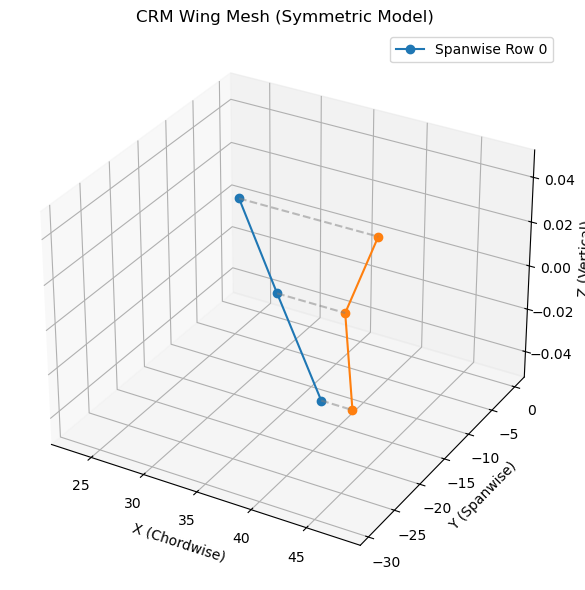

In [17]:
import matplotlib.pyplot as plt
from openaerostruct.meshing.mesh_generator import generate_mesh
from mpl_toolkits.mplot3d import Axes3D

# Generate CRM mesh
mesh_dict = {
    "num_y": 5,
    "num_x": 2,
    "wing_type": "CRM",
    "symmetry": True,
    "num_twist_cp": 5,
}
mesh, _ = generate_mesh(mesh_dict)

# Plot the mesh in 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

for i in range(mesh.shape[0]):
    ax.plot(mesh[i, :, 0], mesh[i, :, 1], mesh[i, :, 2], marker='o', label=f'Spanwise Row {i}' if i==0 else "")
for j in range(mesh.shape[1]):
    ax.plot(mesh[:, j, 0], mesh[:, j, 1], mesh[:, j, 2], color='gray', linestyle='--', alpha=0.5)

ax.set_title("CRM Wing Mesh (Symmetric Model)")
ax.set_xlabel("X (Chordwise)")
ax.set_ylabel("Y (Spanwise)")
ax.set_zlabel("Z (Vertical)")
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
def compute_fitness(prob, w_mass=1.0, w_fuel=0.1, penalty_weight=1e6):
    """
    Computes fitness as a weighted sum of structural mass and fuelburn,
    with penalty for failure, negative CL, or negative fuelburn.

    Returns:
    - Dictionary with fitness and all relevant metrics
    """
    import numpy as np

    try:
        with suppress_output():
            prob.run_model()

        structural_mass = prob.get_val('AS_point_0.total_perf.wing_structural_mass').item()
        fuelburn = prob.get_val('AS_point_0.fuelburn').item()
        failure = np.max(prob.get_val('AS_point_0.wing_perf.failure'))
        CL = prob.get_val('AS_point_0.wing_perf.CL').item()
        CD = prob.get_val('AS_point_0.wing_perf.CD').item()

        penalty = 0.0

        # Penalty for structural failure
        if failure > 0:
            penalty += penalty_weight * failure**2

        # Penalize unphysical values
        if CL < 0:
            penalty += penalty_weight * abs(CL)

        if fuelburn < 0:
            penalty += penalty_weight * abs(fuelburn)
            fuelburn = abs(fuelburn)  # Optional: clamp to positive for reporting

        # ✅ Compute final fitness
        fitness = (w_mass * structural_mass) + (w_fuel * fuelburn) + penalty

        return {
            "fitness": fitness,
            "structural_mass": structural_mass,
            "fuelburn": fuelburn,
            "failure": failure,
            "CL": CL,
            "CD": CD,
        }

    except Exception as e:
        print("⚠️ compute_fitness failed:", e)
        return {
            "fitness": 1e10,
            "structural_mass": 1e10,
            "fuelburn": 1e10,
            "failure": 1e10,
            "CL": 0.0,
            "CD": 0.0,
        }


In [21]:
def update_design_variables(prob, twist_cp_values, thickness_cp_values, alpha_value):
    """
    Updates the design variables (twist_cp, thickness_cp, alpha) in OpenAeroStruct problem.

    Parameters:
    - prob: OpenMDAO Problem instance
    - twist_cp_values: numpy array (shape: [5,])
    - thickness_cp_values: numpy array (shape: [3,])
    - alpha_value: float
    """

    prob.set_val('wing.twist_cp', twist_cp_values)
    prob.set_val('wing.thickness_cp', thickness_cp_values)
    prob.set_val('alpha', alpha_value)

In [39]:
import numpy as np
import random
import time
start_time = time.time()

# GA parameters
population_size = 30
generations = 20
mutation_rate = 0.1
tournament_size = 3

# Design variable definitions
num_twist_cp = 5
num_thickness_cp = 3
twist_bounds = (-10.0, 15.0)
thickness_bounds = (0.05, 0.3)
alpha_bounds = (-5.0, 10.0)

def initialize_population():
    population = []
    for _ in range(population_size):
        twist = np.random.uniform(*twist_bounds, num_twist_cp)
        thickness = np.random.uniform(*thickness_bounds, num_thickness_cp)
        alpha = np.random.uniform(*alpha_bounds)
        population.append((twist, thickness, alpha))
    return population

def tournament_selection(fitness_list):
    selected_idx = np.random.choice(range(len(fitness_list)), tournament_size)
    selected = [fitness_list[i] for i in selected_idx]
    selected.sort(key=lambda x: x[0])
    return selected[0][1]

def crossover(parent1, parent2):
    twist1, thickness1, alpha1 = parent1
    twist2, thickness2, alpha2 = parent2

    child_twist = np.where(np.random.rand(num_twist_cp) < 0.5, twist1, twist2)
    child_thickness = np.where(np.random.rand(num_thickness_cp) < 0.5, thickness1, thickness2)
    child_alpha = alpha1 if random.random() < 0.5 else alpha2

    return (child_twist, child_thickness, child_alpha)

def mutate(individual):
    twist, thickness, alpha = individual
    twist = np.copy(twist)
    thickness = np.copy(thickness)
    for i in range(num_twist_cp):
        if random.random() < mutation_rate:
            twist[i] = np.random.uniform(*twist_bounds)
    for i in range(num_thickness_cp):
        if random.random() < mutation_rate:
            thickness[i] = np.random.uniform(*thickness_bounds)
    if random.random() < mutation_rate:
        alpha = np.random.uniform(*alpha_bounds)
    return (twist, thickness, alpha)

# ----------------------------
# GA Main Loop
# ----------------------------
population = initialize_population()
best_fitness_per_gen = []
best_individual_per_gen = []
fitness_tracking = []

for gen in range(generations):
    fitness_list = []
    fitness_curve = []
    mass_curve = []
    fuel_curve = []

    for individual in population:
        prob = setup_openaerostruct_problem()
        twist_cp, thickness_cp, alpha = individual
        update_design_variables(prob, twist_cp, thickness_cp, alpha)

        metrics = compute_fitness(prob, w_mass=1.0, w_fuel=0.1)
        fitness = metrics["fitness"]
        mass = metrics["structural_mass"]
        fuelburn = metrics["fuelburn"]
        failure = metrics["failure"]
        CL = metrics["CL"]
        CD = metrics["CD"]

        fitness_list.append((fitness, individual, mass, fuelburn, failure, CL, CD))

    fitness_list.sort(key=lambda x: x[0])
    best_fitness, best_individual, best_mass, best_fuelburn, best_failure, best_CL, best_CD = fitness_list[0]
    LD_ratio = best_CL / best_CD if best_CD != 0 else 0.0

    best_fitness_per_gen.append(best_fitness)
    best_individual_per_gen.append(best_individual)
    fitness_tracking.append(fitness_list)

    print(f"Generation {gen+1}: Fitness = {best_fitness:.3f}, Mass = {best_mass:.3f}, Fuelburn = {best_fuelburn:.3f}, Failure = {best_failure:.3f}, CL = {best_CL:.3f}, CD = {best_CD:.3f}, L/D = {LD_ratio:.2f}")

    # Create next generation
    new_population = []
    for _ in range(population_size):
        parent1 = tournament_selection(fitness_list)
        parent2 = tournament_selection(fitness_list)
        child = crossover(parent1, parent2)
        child = mutate(child)
        new_population.append(child)

    population = new_population

print("\n✅ GA Optimization Completed!")
end_time = time.time()
total_time = end_time - start_time


Generation 1: Fitness = 132965.943, Mass = 119332.189, Fuelburn = 136337.544, Failure = -0.708, CL = 0.601, CD = 0.036, L/D = 16.64
Generation 2: Fitness = 134827.606, Mass = 120805.815, Fuelburn = 140217.907, Failure = -0.132, CL = 0.796, CD = 0.049, L/D = 16.35
Generation 3: Fitness = 117216.202, Mass = 85782.284, Fuelburn = 314339.184, Failure = -0.448, CL = 0.280, CD = 0.035, L/D = 8.09
Generation 4: Fitness = 95009.942, Mass = 83838.849, Fuelburn = 111710.936, Failure = -0.509, CL = 0.591, CD = 0.034, L/D = 17.17
Generation 5: Fitness = 86176.351, Mass = 74162.106, Fuelburn = 120142.444, Failure = -0.568, CL = 0.487, CD = 0.031, L/D = 15.57
Generation 6: Fitness = 85842.406, Mass = 74218.391, Fuelburn = 116240.154, Failure = -0.551, CL = 0.767, CD = 0.048, L/D = 15.99
Generation 7: Fitness = 83490.428, Mass = 74155.757, Fuelburn = 93346.701, Failure = -0.073, CL = 0.858, CD = 0.045, L/D = 19.11
Generation 8: Fitness = 83810.314, Mass = 74155.826, Fuelburn = 96544.880, Failure = -0

In [41]:
# Extract final best solution
best_gen_index = np.argmin(best_fitness_per_gen)
final_best_fitness = best_fitness_per_gen[best_gen_index]
final_best_individual = best_individual_per_gen[best_gen_index]
twist_best, thickness_best, alpha_best = final_best_individual

# Print summary
print("\nFinal Best Design Found:")
print(f"Generation          : {best_gen_index + 1}")
print(f"Best Fitness        : {final_best_fitness:.3f}")
print(f"Best Twist CPs      : {twist_best}")
print(f"Best Thickness CPs  : {thickness_best}")
print(f"Best Alpha          : {alpha_best:.3f}")
print(f"⏱️ Total Time Taken  : {total_time:.2f} seconds")

#Save best solution to CSV
import pandas as pd

best_data = pd.DataFrame({
    "Generation": [best_gen_index + 1],
    "Fitness": [final_best_fitness],
    "Alpha": [alpha_best],
    "Twist": [twist_best.tolist()],
    "Thickness": [thickness_best.tolist()],
    "Total Time (s)": [total_time]
})
best_data.to_csv("final_best_solution.csv", index=False)
print("📁 Saved best solution to 'final_best_solution.csv'")



Final Best Design Found:
Generation          : 16
Best Fitness        : 77233.213
Best Twist CPs      : [-3.04408284 13.33571236 13.11964113 13.32918733  1.39010986]
Best Thickness CPs  : [0.05021997 0.05003079 0.05155686]
Best Alpha          : 6.838
⏱️ Total Time Taken  : 181.85 seconds
📁 Saved best solution to 'final_best_solution.csv'


In [43]:
# Re-evaluate best design for summary
prob = setup_openaerostruct_problem()
update_design_variables(prob, twist_best, thickness_best, alpha_best)
metrics = compute_fitness(prob)

mass = metrics["structural_mass"]
fuelburn = metrics["fuelburn"]
failure = metrics["failure"]
CL = metrics["CL"]
CD = metrics["CD"]
LD_ratio = CL / CD if CD != 0 else 0.0

print("\n📊 Performance Summary of Best Design")
print(f"Structural Mass (kg):     {mass:.3f}")
print(f"Fuelburn (kg):            {fuelburn:.3f}")
print(f"Max Failure Index:        {failure:.3f}")
print(f"Lift Coefficient (CL):    {CL:.3f}")
print(f"Drag Coefficient (CD):    {CD:.3f}")
print(f"Lift-to-Drag Ratio (L/D): {LD_ratio:.2f}")



📊 Performance Summary of Best Design
Structural Mass (kg):     68185.562
Fuelburn (kg):            90476.516
Max Failure Index:        -0.023
Lift Coefficient (CL):    0.941
Drag Coefficient (CD):    0.049
Lift-to-Drag Ratio (L/D): 19.11


In [49]:
fitness_curve.append(best_fitness_per_gen)
mass_curve.append(metrics["structural_mass"])
fuel_curve.append(metrics["fuelburn"])

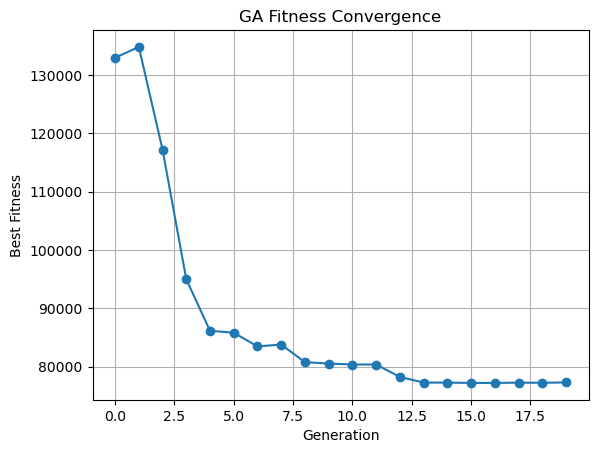

In [59]:
# Plot fitness convergence
import matplotlib.pyplot as plt

plt.figure()
plt.plot(best_fitness_per_gen, marker='o')
plt.title("GA Fitness Convergence")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.grid(True)
plt.show()
# Plotting




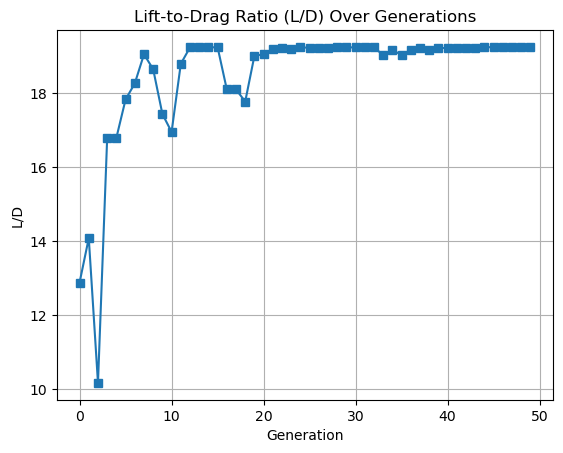

In [117]:
# Plot L/D ratio if stored in fitness_tracking
ld_ratios = []
for generation in fitness_tracking:
    best_CL = generation[0][5]
    best_CD = generation[0][6]
    L_D = best_CL / best_CD if best_CD != 0 else 0
    ld_ratios.append(L_D)

plt.figure()
plt.plot(ld_ratios, marker='s')
plt.title("Lift-to-Drag Ratio (L/D) Over Generations")
plt.xlabel("Generation")
plt.ylabel("L/D")
plt.grid(True)
plt.show()

Generation 1: Fitness = 126638.992, Mass = 194099.645, Fuel = 164595.077, CL = 0.915, CD = 0.051
Generation 2: Fitness = 106763.932, Mass = 94953.122, Fuel = 190433.552, CL = 0.322, CD = 0.027
Generation 3: Fitness = 96451.351, Mass = 76199.973, Fuel = 202513.788, CL = 0.287, CD = 0.027
Generation 4: Fitness = 78754.261, Mass = 67329.948, Fuel = 242204.676, CL = 0.247, CD = 0.027
Generation 5: Fitness = 78227.468, Mass = 67330.016, Fuel = 242555.749, CL = 0.247, CD = 0.027
Generation 6: Fitness = 78222.022, Mass = 67310.303, Fuel = 147752.941, CL = 0.362, CD = 0.028
Generation 7: Fitness = 77758.297, Mass = 67300.954, Fuel = 108655.527, CL = 0.620, CD = 0.038
Generation 8: Fitness = 77083.197, Mass = 67324.474, Fuel = 113299.506, CL = 0.832, CD = 0.052
Generation 9: Fitness = 76638.615, Mass = 67301.488, Fuel = 98754.556, CL = 0.717, CD = 0.040
Generation 10: Fitness = 76488.888, Mass = 67294.322, Fuel = 93467.207, CL = 0.709, CD = 0.038
Generation 11: Fitness = 76488.667, Mass = 67295

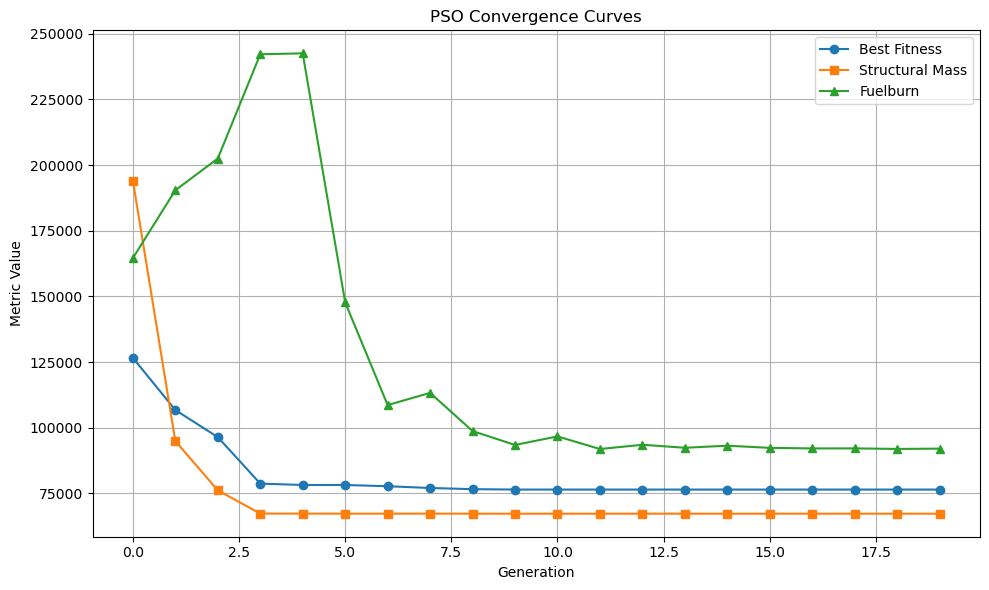

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd


# PSO Parameters
swarm_size = 30
generations = 20
w = 0.7  # inertia weight
c1 = 1.5  # cognitive
c2 = 1.5  # social

# Design variable definitions
num_twist_cp = 5
num_thickness_cp = 3
twist_bounds = (-10.0, 15.0)
thickness_bounds = (0.05, 0.3)
alpha_bounds = (-5.0, 10.0)

# Initialize swarm
def initialize_swarm():
    swarm = []
    for _ in range(swarm_size):
        twist = np.random.uniform(*twist_bounds, num_twist_cp)
        thickness = np.random.uniform(*thickness_bounds, num_thickness_cp)
        alpha = np.random.uniform(*alpha_bounds)
        position = (twist, thickness, alpha)

        v_twist = np.zeros(num_twist_cp)
        v_thick = np.zeros(num_thickness_cp)
        v_alpha = 0.0
        velocity = (v_twist, v_thick, v_alpha)

        swarm.append((position, velocity))
    return swarm

# PSO Main
start_time = time.time()
swarm = initialize_swarm()
pbest_positions = []
pbest_fitness = []

# Initialize pbest
for position, _ in swarm:
    prob = setup_openaerostruct_problem()
    twist, thickness, alpha = position
    update_design_variables(prob, twist, thickness, alpha)
    metrics = compute_fitness(prob)
    pbest_positions.append(position)
    pbest_fitness.append(metrics["fitness"])

gbest_index = np.argmin(pbest_fitness)
gbest_position = pbest_positions[gbest_index]
gbest_fitness = pbest_fitness[gbest_index]

fitness_curve = []
mass_curve = []
fuel_curve = []

for gen in range(generations):
    for i in range(swarm_size):
        position, velocity = swarm[i]
        twist, thickness, alpha = position
        v_twist, v_thick, v_alpha = velocity

        # Velocity update
        r1, r2 = np.random.rand(), np.random.rand()
        v_twist = w * v_twist + c1 * r1 * (pbest_positions[i][0] - twist) + c2 * r2 * (gbest_position[0] - twist)
        v_thick = w * v_thick + c1 * r1 * (pbest_positions[i][1] - thickness) + c2 * r2 * (gbest_position[1] - thickness)
        v_alpha = w * v_alpha + c1 * r1 * (pbest_positions[i][2] - alpha) + c2 * r2 * (gbest_position[2] - alpha)

        # Position update
        twist = np.clip(twist + v_twist, *twist_bounds)
        thickness = np.clip(thickness + v_thick, *thickness_bounds)
        alpha = np.clip(alpha + v_alpha, *alpha_bounds)

        swarm[i] = ((twist, thickness, alpha), (v_twist, v_thick, v_alpha))

        # Evaluate
        prob = setup_openaerostruct_problem()
        update_design_variables(prob, twist, thickness, alpha)
        metrics = compute_fitness(prob)
        fit = metrics["fitness"]

        # Update pbest
        if fit < pbest_fitness[i]:
            pbest_positions[i] = (twist, thickness, alpha)
            pbest_fitness[i] = fit

    # Update gbest
    gbest_index = np.argmin(pbest_fitness)
    gbest_position = pbest_positions[gbest_index]
    gbest_fitness = pbest_fitness[gbest_index]

    fitness_curve.append(gbest_fitness)
    mass_curve.append(metrics["structural_mass"])
    fuel_curve.append(metrics["fuelburn"])

    print(f"Generation {gen+1}: Fitness = {gbest_fitness:.3f}, Mass = {metrics['structural_mass']:.3f}, Fuel = {metrics['fuelburn']:.3f}, CL = {metrics['CL']:.3f}, CD = {metrics['CD']:.3f}")

end_time = time.time()
total_time = end_time - start_time

# Final best evaluation
twist_best, thickness_best, alpha_best = gbest_position
prob = setup_openaerostruct_problem()
update_design_variables(prob, twist_best, thickness_best, alpha_best)
metrics = compute_fitness(prob)

LD_ratio = metrics["CL"] / metrics["CD"] if metrics["CD"] != 0 else 0

final_best_gen = np.argmin(fitness_curve)

print("Final Best Design Found:")
print(f"Generation          : {final_best_gen + 1}")
print(f"Best Fitness        : {gbest_fitness:.3f}")
print(f"Best Twist CPs      : {twist_best}")
print(f"Best Thickness CPs  : {thickness_best}")
print(f"Best Alpha          : {alpha_best:.3f}")
print(f"⏱️ Total Time Taken  : {total_time:.2f} seconds")

print("PSO Optimization Completed!")
print("\n📊 Performance Summary (Best Particle)")
print(f"Structural Mass (kg):     {metrics['structural_mass']:.3f}")
print(f"Fuelburn (kg):            {metrics['fuelburn']:.3f}")
print(f"Max Failure Index:        {metrics['failure']:.3f}")
print(f"Lift Coefficient (CL):    {metrics['CL']:.3f}")
print(f"Drag Coefficient (CD):    {metrics['CD']:.3f}")
print(f"Lift-to-Drag Ratio (L/D): {LD_ratio:.2f}")
print(f"Best Alpha (deg):         {alpha_best:.3f}")
print(f"Run Time (s):             {total_time:.2f}")

# Save to CSV
best_data = pd.DataFrame({
    "Fitness": [gbest_fitness],
    "Alpha": [alpha_best],
    "Twist": [twist_best.tolist()],
    "Thickness": [thickness_best.tolist()],
    "Mass": [metrics["structural_mass"]],
    "Fuelburn": [metrics["fuelburn"]],
    "Time (s)": [total_time]
})
best_data.to_csv("pso_best_solution.csv", index=False)
print("📁 Saved best solution to 'pso_best_solution.csv'")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(fitness_curve, label="Best Fitness", marker='o')
plt.plot(mass_curve, label="Structural Mass", marker='s')
plt.plot(fuel_curve, label="Fuelburn", marker='^')
plt.title("PSO Convergence Curves")
plt.xlabel("Generation")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Generation 1: Fitness = 136541.642, Mass = 156041.533, Fuel = 146232.649, CL = 0.731, CD = 0.041
Generation 2: Fitness = 125459.313, Mass = 128122.870, Fuel = 132633.168, CL = 0.774, CD = 0.044
Generation 3: Fitness = 106060.581, Mass = 102373.387, Fuel = 118774.728, CL = 0.800, CD = 0.046
Generation 4: Fitness = 92414.542, Mass = 86213.369, Fuel = 110071.896, CL = 0.800, CD = 0.046
Generation 5: Fitness = 82471.137, Mass = 77452.301, Fuel = 105569.799, CL = 0.800, CD = 0.046
Generation 6: Fitness = 77356.079, Mass = 81900.293, Fuel = 107843.221, CL = 0.800, CD = 0.046
Generation 7: Fitness = 77353.486, Mass = 78193.596, Fuel = 106174.092, CL = 0.796, CD = 0.046
Generation 8: Fitness = 77353.486, Mass = 87836.243, Fuel = 110890.396, CL = 0.804, CD = 0.046
Generation 9: Fitness = 77352.086, Mass = 73559.371, Fuel = 103512.187, CL = 0.799, CD = 0.046
Generation 10: Fitness = 77352.086, Mass = 75927.186, Fuel = 104715.259, CL = 0.800, CD = 0.046
Generation 11: Fitness = 77352.086, Mass = 

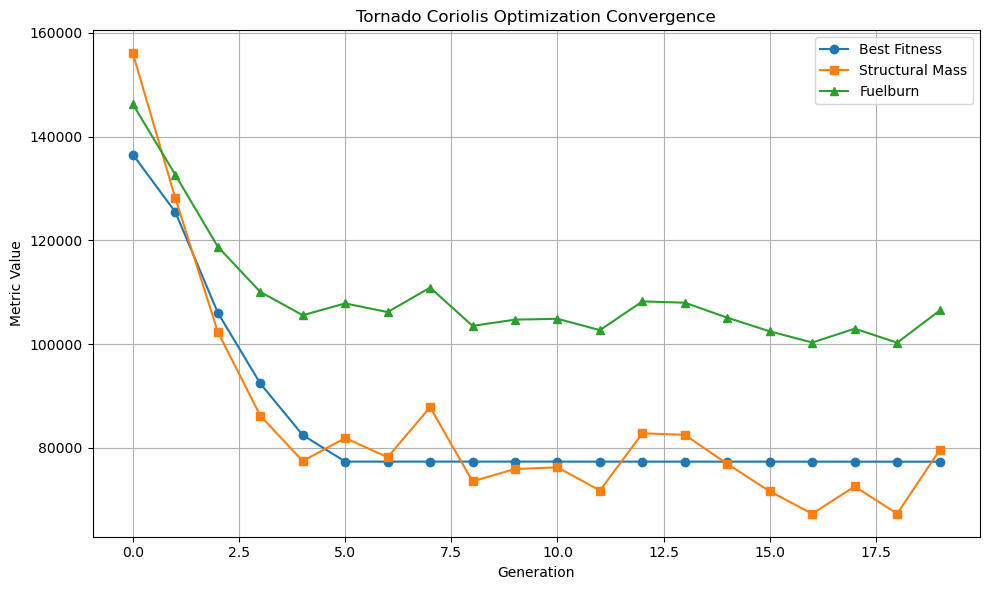

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time


# Tornado Coriolis Optimizer (TOC) Parameters
population_size = 30
generations = 20
inertia = 0.7
coriolis_coeff = 0.01

# Design variable dimensions
num_twist_cp = 5
num_thickness_cp = 3
total_dim = num_twist_cp + num_thickness_cp + 1  # +1 for alpha

# Variable bounds
twist_bounds = (-10.0, 15.0)
thickness_bounds = (0.05, 0.3)
alpha_bounds = (-5.0, 10.0)

# Bound helper
def apply_bounds(position):
    twist = np.clip(position[:num_twist_cp], *twist_bounds)
    thickness = np.clip(position[num_twist_cp:num_twist_cp+num_thickness_cp], *thickness_bounds)
    alpha = np.clip(position[-1], *alpha_bounds)
    return np.concatenate([twist, thickness, [alpha]])

# Initialization
np.random.seed(42)
start_time = time.time()

positions = []
fitnesses = []

for _ in range(population_size):
    twist = np.random.uniform(*twist_bounds, num_twist_cp)
    thickness = np.random.uniform(*thickness_bounds, num_thickness_cp)
    alpha = np.random.uniform(*alpha_bounds)
    vector = np.concatenate([twist, thickness, [alpha]])

    prob = setup_openaerostruct_problem()
    update_design_variables(prob, twist, thickness, alpha)
    metrics = compute_fitness(prob)
    fitness = metrics["fitness"]

    positions.append(vector)
    fitnesses.append(fitness)

positions = np.array(positions)
fitnesses = np.array(fitnesses)

best_index = np.argmin(fitnesses)
gbest = positions[best_index].copy()
gbest_fitness = fitnesses[best_index]

fitness_curve = []
mass_curve = []
fuel_curve = []

for gen in range(generations):
    new_positions = []
    new_fitnesses = []

    for i in range(population_size):
        R = np.random.randn(total_dim)
        direction = gbest - positions[i]
        noise = np.random.randn(total_dim)
        spiral_vector = inertia * direction + coriolis_coeff * noise
        new_position = positions[i] + spiral_vector
        new_position = apply_bounds(new_position)

        twist = new_position[:num_twist_cp]
        thickness = new_position[num_twist_cp:num_twist_cp+num_thickness_cp]
        alpha = new_position[-1]

        prob = setup_openaerostruct_problem()
        update_design_variables(prob, twist, thickness, alpha)
        metrics = compute_fitness(prob)
        fit = metrics["fitness"]

        new_positions.append(new_position)
        new_fitnesses.append(fit)

        if fit < gbest_fitness:
            gbest = new_position.copy()
            gbest_fitness = fit

    positions = np.array(new_positions)
    fitnesses = np.array(new_fitnesses)

    fitness_curve.append(gbest_fitness)
    mass_curve.append(metrics["structural_mass"])
    fuel_curve.append(metrics["fuelburn"])

    print(f"Generation {gen+1}: Fitness = {gbest_fitness:.3f}, Mass = {metrics['structural_mass']:.3f}, Fuel = {metrics['fuelburn']:.3f}, CL = {metrics['CL']:.3f}, CD = {metrics['CD']:.3f}")

end_time = time.time()
total_time = end_time - start_time

# Extract best design
twist_best = gbest[:num_twist_cp]
thickness_best = gbest[num_twist_cp:num_twist_cp+num_thickness_cp]
alpha_best = gbest[-1]

# Re-evaluate best design
prob = setup_openaerostruct_problem()
update_design_variables(prob, twist_best, thickness_best, alpha_best)
metrics = compute_fitness(prob)

LD_ratio = metrics["CL"] / metrics["CD"] if metrics["CD"] != 0 else 0
final_best_gen = np.argmin(fitness_curve)

print("\nFinal Best Design Found:")
print(f"Generation          : {final_best_gen + 1}")
print(f"Best Fitness        : {gbest_fitness:.3f}")
print(f"Best Twist CPs      : {twist_best}")
print(f"Best Thickness CPs  : {thickness_best}")
print(f"Best Alpha          : {alpha_best:.3f}")
print(f"⏱️ Total Time Taken  : {total_time:.2f} seconds")

print("\n📊 Performance Summary (Best Individual)")
print(f"Structural Mass (kg):     {metrics['structural_mass']:.3f}")
print(f"Fuelburn (kg):            {metrics['fuelburn']:.3f}")
print(f"Max Failure Index:        {metrics['failure']:.3f}")
print(f"Lift Coefficient (CL):    {metrics['CL']:.3f}")
print(f"Drag Coefficient (CD):    {metrics['CD']:.3f}")
print(f"Lift-to-Drag Ratio (L/D): {LD_ratio:.2f}")

# Save to CSV
best_data = pd.DataFrame({
    "Generation": [final_best_gen + 1],
    "Fitness": [gbest_fitness],
    "Alpha": [alpha_best],
    "Twist": [twist_best.tolist()],
    "Thickness": [thickness_best.tolist()],
    "Mass": [metrics["structural_mass"]],
    "Fuelburn": [metrics["fuelburn"]],
    "Time (s)": [total_time]
})
best_data.to_csv("tornado_best_solution.csv", index=False)
print("📁 Saved best solution to 'tornado_best_solution.csv'")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(fitness_curve, label="Best Fitness", marker='o')
plt.plot(mass_curve, label="Structural Mass", marker='s')
plt.plot(fuel_curve, label="Fuelburn", marker='^')
plt.title("Tornado Coriolis Optimization Convergence")
plt.xlabel("Generation")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
